In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

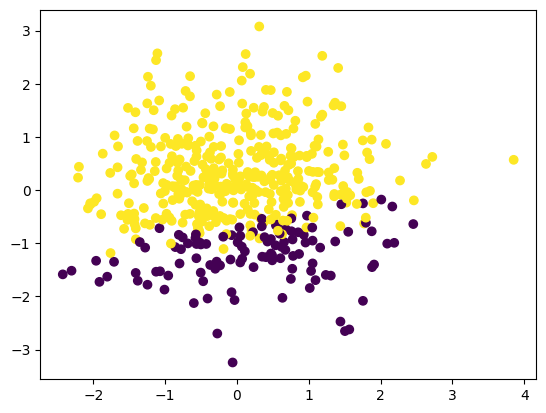

In [3]:
# Sample Code for generating datasets
size = 500
dim=2
noise_bound = 0.2

seed = 42
np.random.seed(seed)

X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [23]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


50. Training loss: 0.4210863364107006, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.4052693942293411
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.34443109894084123, Val loss:0.35415496178424605
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.3259658018222963, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.3113486162459987, Val loss:0.3242394100832966


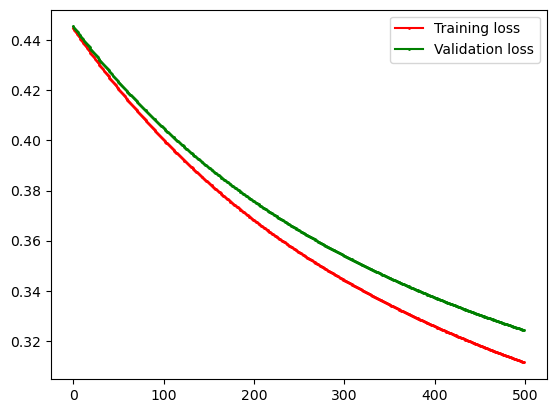

In [24]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function, gradient, and activation function.
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [14]:
# Get the Prediction
y_val_pred = model.predict(X_val)

Logistic Regression Evaluation
Accuracy  : 0.8775
Precision : 0.8784
Recall    : 0.8986
F1-score  : 0.8884


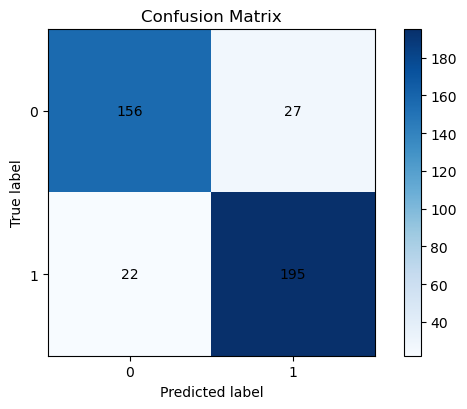

{'Accuracy': 0.8775,
 'Precision': 0.8783783783783784,
 'Recall': 0.8986175115207373,
 'F1-score': 0.8883826879271071}

In [15]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

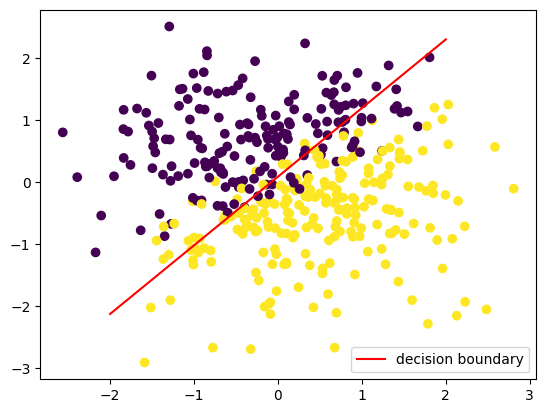

In [ ]:
# Plot
plt.scatter(X_val[:,1],X_val[:,2],c=y_val) #X_val[:,1] 與 X_val[:,2]：分別取出驗證集中的兩個特徵（跳過 X_val[:,0]，因為那一欄全是 1（截距項），不是特徵。#c=y_val：根據標籤（0 或 1）來決定點的顏色。

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()

50. Training loss: 0.31214565926023174, Val loss:0.3238995705537948
100. Training loss: 0.26802535795005134, Val loss:0.28459011684914537
150. Training loss: 0.24507991801016668, Val loss:0.26367143739005755
200. Training loss: 0.23025970529698725, Val loss:0.24981367489682632
250. Training loss: 0.21963615020155505, Val loss:0.23967468756947907
300. Training loss: 0.2115547767275018, Val loss:0.23184417444050137
350. Training loss: 0.20516346620008113, Val loss:0.2255827485342569
400. Training loss: 0.1999656677345639, Val loss:0.22044961112666256
450. Training loss: 0.195647628340575, Val loss:0.21616005232291835
500. Training loss: 0.19199945372601435, Val loss:0.21251993712270312


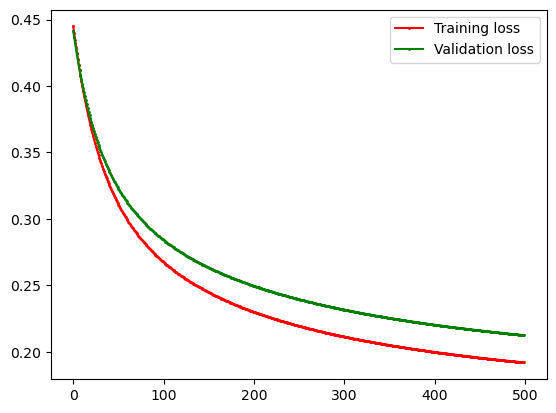

Logistic Regression Evaluation
Accuracy  : 0.9225
Precision : 0.9330
Recall    : 0.9266
F1-score  : 0.9298


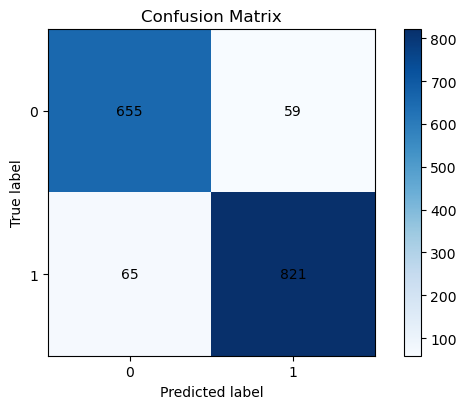

50. Training loss: 0.4210863364107006, Val loss:0.42389318391426317
100. Training loss: 0.4006650658061349, Val loss:0.4052693942293411
150. Training loss: 0.38331041463875526, Val loss:0.3894644471413472
200. Training loss: 0.36844391326627834, Val loss:0.37594512076571973
250. Training loss: 0.35560590258631664, Val loss:0.36428763531349373
300. Training loss: 0.34443109894084123, Val loss:0.35415496178424605
350. Training loss: 0.33462857869617535, Val loss:0.3452784421002676
400. Training loss: 0.3259658018222963, Val loss:0.3374431872521515
450. Training loss: 0.3182560482209092, Val loss:0.33047660104180177
500. Training loss: 0.3113486162459987, Val loss:0.3242394100832966


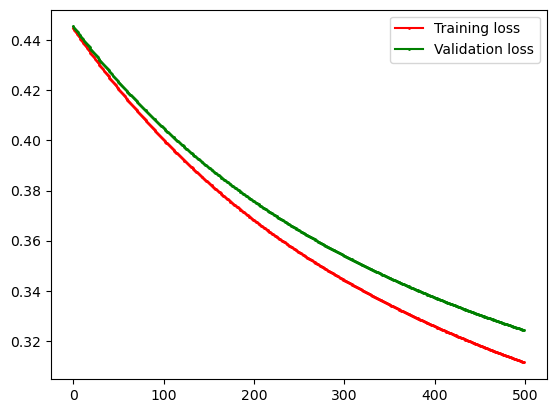

Logistic Regression Evaluation
Accuracy  : 0.9113
Precision : 0.9346
Recall    : 0.9029
F1-score  : 0.9185


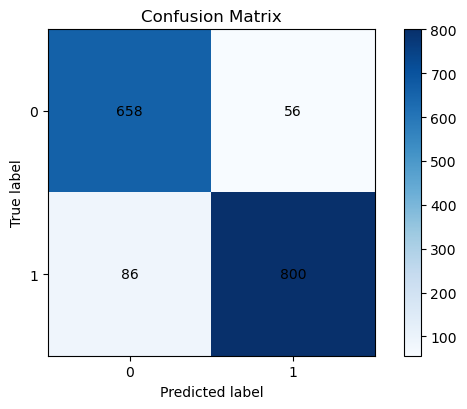

50. Training loss: 0.44221977024873593, Val loss:0.4436168074363421
100. Training loss: 0.4396594302179652, Val loss:0.4412701641807759
150. Training loss: 0.4371436725613986, Val loss:0.43896472084268623
200. Training loss: 0.4346715536135045, Val loss:0.4366996003801621
250. Training loss: 0.4322421495919633, Val loss:0.43447394458012223
300. Training loss: 0.4298545563023576, Val loss:0.43228691374881156
350. Training loss: 0.42750788883734553, Val loss:0.43013768639915717
400. Training loss: 0.42520128127118983, Val loss:0.4280254589357611
450. Training loss: 0.422933886350463, Val loss:0.4259494453382512
500. Training loss: 0.42070487518169253, Val loss:0.42390887684365186


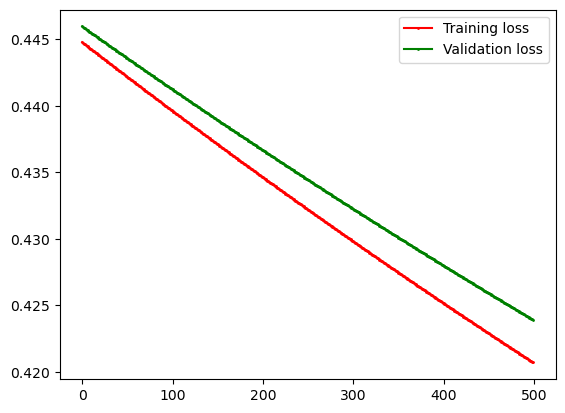

Logistic Regression Evaluation
Accuracy  : 0.8319
Precision : 0.8668
Recall    : 0.8228
F1-score  : 0.8442


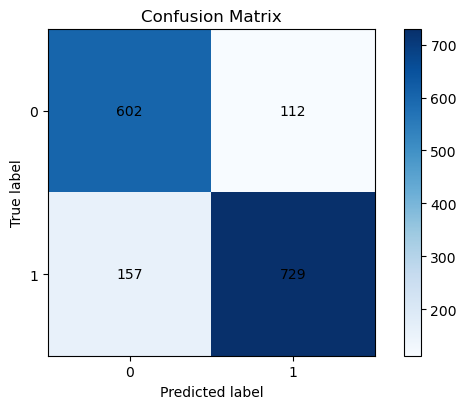

In [25]:

# Task
for lr in [0.1, 0.01, 0.001]:
    np.random.seed(42)
    model0 = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
    model0.fit(X_train,y_train,lr=lr,n_iteration =500,val_ratio=0.2)
    y_val_pred = model0.predict(X_val)
    evaluate_binary_classifier(y_true=y_val,y_pred=y_val_pred,title='Logistic Regression Evaluation')